# 🦠 COVID-19 Mexico Dataset — Exploratory Data Analysis (EDA)

**Internship Task 2 | EDA on Real-World Healthcare Data**

---

## 📌 About the Dataset
This dataset contains COVID-19 patient records from Mexico, including demographic information,
medical conditions, and outcomes. It contains ~1 million records.

**Key Variables:**
| Column | Description |
|---|---|
| USMER | Treated in USMER units (1=Yes, 2=No) |
| MEDICAL_UNIT | Type of medical unit |
| SEX | 1=Female, 2=Male |
| PATIENT_TYPE | 1=Returned home, 2=Hospitalized |
| DATE_DIED | Date of death (9999-99-99 = survived) |
| INTUBED | Was patient intubated? (1=Yes, 2=No, 97=N/A) |
| PNEUMONIA | Has pneumonia? |
| AGE | Age of patient |
| PREGNANT | Is patient pregnant? |
| DIABETES | Has diabetes? |
| COPD | Has COPD? |
| ASTHMA | Has asthma? |
| INMSUPR | Immunosuppressed? |
| HIPERTENSION | Has hypertension? |
| OTHER_DISEASE | Other disease? |
| CARDIOVASCULAR | Cardiovascular disease? |
| OBESITY | Is obese? |
| RENAL_CHRONIC | Chronic renal disease? |
| TOBACCO | Tobacco user? |
| CLASIFFICATION_FINAL | COVID test result (1-3=Positive, 4-7=Negative/Other) |
| ICU | Admitted to ICU? |

---
## 🤔 Step 1: Meaningful Questions Before Analysis

Before diving in, let's ask important questions:

1. **Mortality:** What is the overall death rate in this dataset?
2. **Demographics:** How does age and sex affect COVID-19 outcomes?
3. **Comorbidities:** Which pre-existing conditions (diabetes, hypertension, obesity) are most common in severe/fatal cases?
4. **Hospitalization:** What factors predict whether a patient is hospitalized vs. sent home?
5. **ICU & Intubation:** What percentage of patients needed ICU or intubation?
6. **Data Quality:** Are there missing values, invalid codes (97, 98, 99), or anomalies?
7. **Trends:** Is there a time trend in the number of cases or deaths?

---
## 📦 Step 2: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


---
## 📂 Step 3: Load the Dataset

In [ ]:
# Load compressed CSV
df = pd.read_csv("E:\Ineternship\Covid Data.csv")

print(f'✅ Dataset loaded!')
print(f'📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded!
📊 Shape: 1,048,575 rows × 21 columns


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97


---
## 🔍 Step 4: Data Structure Exploration

In [ ]:
print('=== DATA TYPES ===')
print(df.dtypes)
print()
print('=== SHAPE ===')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')

=== DATA TYPES ===
USMER                    int64
MEDICAL_UNIT             int64
SEX                      int64
PATIENT_TYPE             int64
DATE_DIED               object
INTUBED                  int64
PNEUMONIA                int64
AGE                      int64
PREGNANT                 int64
DIABETES                 int64
COPD                     int64
ASTHMA                   int64
INMSUPR                  int64
HIPERTENSION             int64
OTHER_DISEASE            int64
CARDIOVASCULAR           int64
OBESITY                  int64
RENAL_CHRONIC            int64
TOBACCO                  int64
CLASIFFICATION_FINAL     int64
ICU                      int64
dtype: object

=== SHAPE ===
Rows: 1,048,575 | Columns: 21


In [ ]:
print('=== BASIC STATISTICS ===')
df.describe()

=== BASIC STATISTICS ===


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,1.632194e+00,8.980565e+00,1.499259e+00,1.190765e+00,7.952288e+01,3.346831e+00,4.179410e+01,4.976558e+01,2.186404e+00,2.260569e+00,2.242626e+00,2.298132e+00,2.128989e+00,2.435143e+00,2.261810e+00,2.125176e+00,2.257180e+00,2.214333e+00,5.305653e+00,7.955397e+01
std,4.822084e-01,3.723278e+00,4.999997e-01,3.929041e-01,3.686889e+01,1.191288e+01,1.690739e+01,4.751073e+01,5.424242e+00,5.132258e+00,5.114089e+00,5.462843e+00,5.236397e+00,6.646676e+00,5.194850e+00,5.175445e+00,5.135354e+00,5.323097e+00,1.881165e+00,3.682307e+01
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.000000e+00,4.000000e+00,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,3.000000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,9.700000e+01
50%,2.000000e+00,1.200000e+01,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,4.000000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,6.000000e+00,9.700000e+01
75%,2.000000e+00,1.200000e+01,2.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,5.300000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,7.000000e+00,9.700000e+01
max,2.000000e+00,1.300000e+01,2.000000e+00,2.000000e+00,9.900000e+01,9.900000e+01,1.210000e+02,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,7.000000e+00,9.900000e+01


In [ ]:
# Check missing values
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

if missing.sum() == 0:
    print('✅ No null values found! (Note: Missing data may be encoded as 97, 98, 99)')

=== MISSING VALUES ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
✅ No null values found! (Note: Missing data may be encoded as 97, 98, 99)


In [ ]:
# Check special codes: 97=N/A, 98=Ignored, 99=Missing
special_cols = ['INTUBED', 'PREGNANT', 'ICU']
print('=== SPECIAL CODES (97/98/99) ===')
for col in special_cols:
    if col in df.columns:
        count_97 = (df[col] == 97).sum()
        count_98 = (df[col] == 98).sum()
        count_99 = (df[col] == 99).sum()
        print(f'{col}: 97={count_97:,} | 98={count_98:,} | 99={count_99:,}')

=== SPECIAL CODES (97/98/99) ===
INTUBED: 97=848,544 | 98=0 | 99=7,325
PREGNANT: 97=523,511 | 98=3,754 | 99=0
ICU: 97=848,544 | 98=0 | 99=7,488


---
## 🧹 Step 5: Data Cleaning & Feature Engineering

In [ ]:
# Create DIED column: if DATE_DIED is a real date (not '9999-99-99'), patient died
df['DIED'] = df['DATE_DIED'].apply(lambda x: 0 if str(x).strip() == '9999-99-99' else 1)

# Convert DATE_DIED to datetime (keep only real dates)
df['DATE_DIED_PARSED'] = pd.to_datetime(df['DATE_DIED'], errors='coerce')

# COVID Positive: CLASIFFICATION_FINAL 1, 2, 3 = Positive
df['COVID_POSITIVE'] = df['CLASIFFICATION_FINAL'].apply(lambda x: 1 if x in [1, 2, 3] else 0)

# Age groups
bins = [0, 18, 30, 45, 60, 75, 120]
labels = ['0-18', '19-30', '31-45', '46-60', '61-75', '75+']
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=bins, labels=labels, right=True)

# Sex label
df['SEX_LABEL'] = df['SEX'].map({1: 'Female', 2: 'Male'})

print(f'✅ Feature engineering done!')
print(f'Deaths: {df["DIED"].sum():,} | Survived: {(df["DIED"]==0).sum():,}')
print(f'COVID Positive: {df["COVID_POSITIVE"].sum():,}')

✅ Feature engineering done!
Deaths: 76,942 | Survived: 971,633
COVID Positive: 391,979


---
## 📊 Step 6: Univariate Analysis

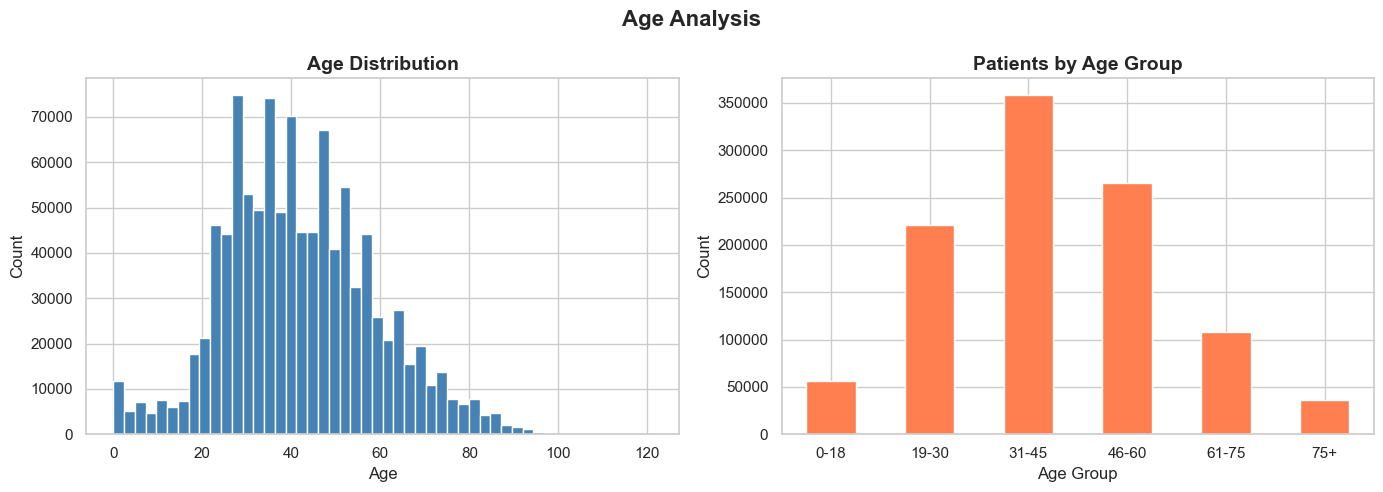

Mean Age: 41.8 | Median: 40 | Std: 16.9


In [ ]:
# AGE Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['AGE'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

df['AGE_GROUP'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Patients by Age Group', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Age Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Mean Age: {df["AGE"].mean():.1f} | Median: {df["AGE"].median():.0f} | Std: {df["AGE"].std():.1f}')

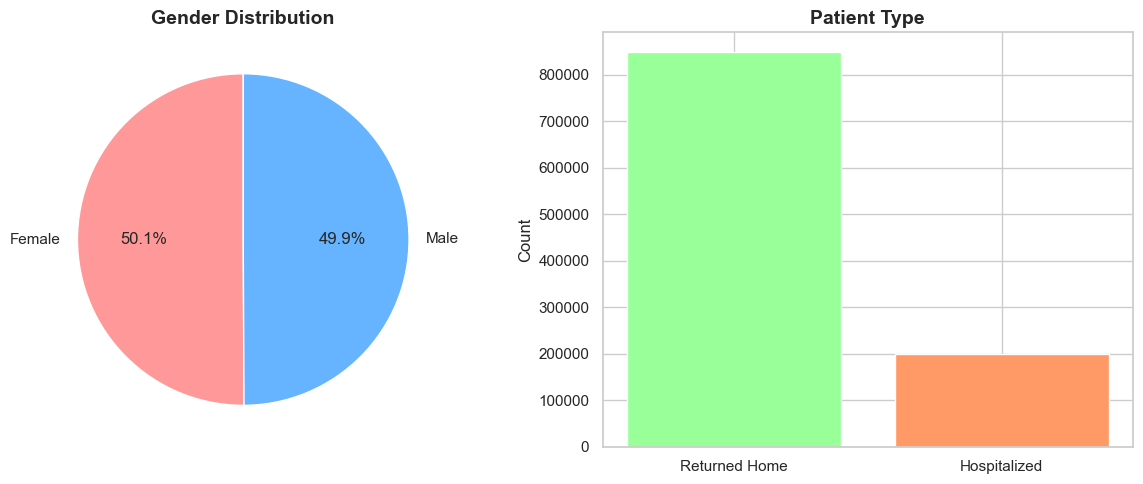

In [ ]:
# Sex & Patient Type Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sex_counts = df['SEX_LABEL'].value_counts()
axes[0].pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%',
            colors=['#ff9999', '#66b3ff'], startangle=90)
axes[0].set_title('Gender Distribution', fontsize=14, fontweight='bold')

pt_counts = df['PATIENT_TYPE'].value_counts()
pt_labels = {1: 'Returned Home', 2: 'Hospitalized'}
axes[1].bar([pt_labels.get(k, str(k)) for k in pt_counts.index],
            pt_counts.values, color=['#99ff99', '#ff9966'])
axes[1].set_title('Patient Type', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

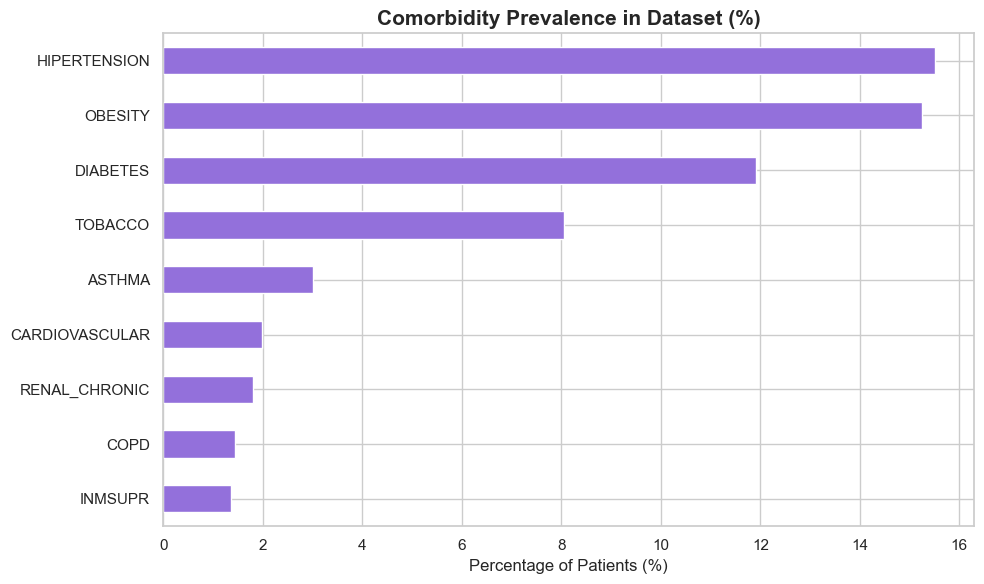

In [ ]:
# Comorbidities Prevalence
comorbidities = ['DIABETES', 'HIPERTENSION', 'OBESITY', 'CARDIOVASCULAR',
                 'COPD', 'ASTHMA', 'RENAL_CHRONIC', 'TOBACCO', 'INMSUPR']

# 1 = Has condition, 2 = Does not have
comorbidity_rates = {}
for col in comorbidities:
    if col in df.columns:
        rate = (df[col] == 1).sum() / len(df) * 100
        comorbidity_rates[col] = rate

comorbidity_df = pd.Series(comorbidity_rates).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
comorbidity_df.plot(kind='barh', color='mediumpurple', edgecolor='white')
plt.title('Comorbidity Prevalence in Dataset (%)', fontsize=15, fontweight='bold')
plt.xlabel('Percentage of Patients (%)')
plt.tight_layout()
plt.show()

---
## 📈 Step 7: Bivariate Analysis — Mortality & Risk Factors

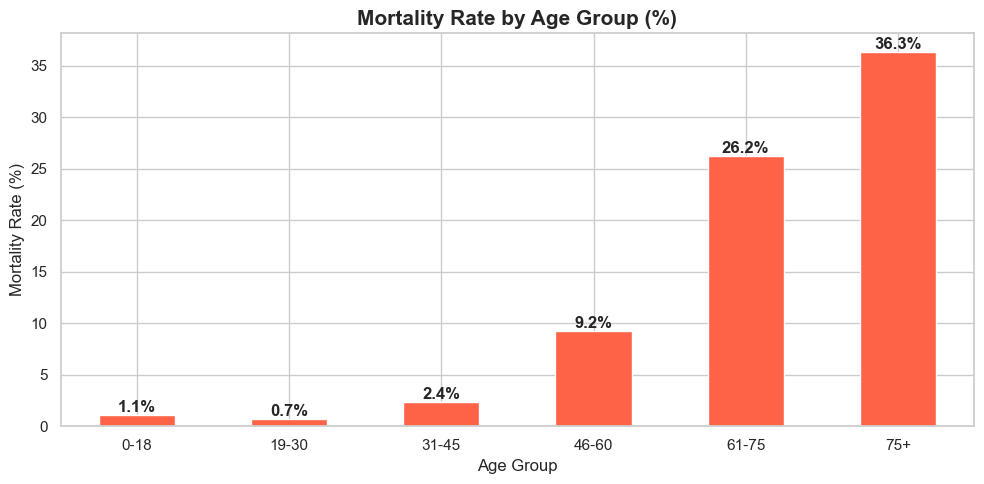

In [ ]:
# Mortality Rate by Age Group
mortality_age = df.groupby('AGE_GROUP')['DIED'].mean() * 100

plt.figure(figsize=(10, 5))
mortality_age.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Mortality Rate by Age Group (%)', fontsize=15, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Mortality Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(mortality_age):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

=== MORTALITY RATE BY SEX ===
SEX_LABEL
Female    5.218792
Male      9.463029


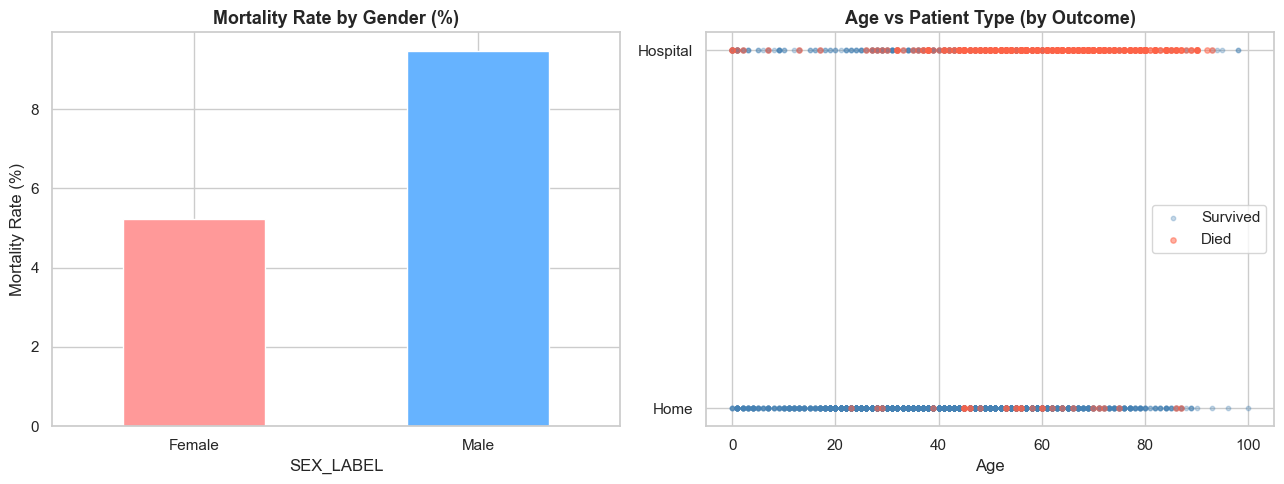

In [ ]:
# Mortality Rate by Sex
mortality_sex = df.groupby('SEX_LABEL')['DIED'].mean() * 100
print('=== MORTALITY RATE BY SEX ===')
print(mortality_sex.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mortality_sex.plot(kind='bar', ax=axes[0], color=['#ff9999', '#66b3ff'], edgecolor='white')
axes[0].set_title('Mortality Rate by Gender (%)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Mortality Rate (%)')
axes[0].tick_params(axis='x', rotation=0)

# Age vs Mortality (scatter with hospitalization)
sample = df.sample(5000, random_state=42)
axes[1].scatter(sample[sample['DIED']==0]['AGE'], sample[sample['DIED']==0]['PATIENT_TYPE'],
               alpha=0.3, color='steelblue', label='Survived', s=10)
axes[1].scatter(sample[sample['DIED']==1]['AGE'], sample[sample['DIED']==1]['PATIENT_TYPE'],
               alpha=0.5, color='tomato', label='Died', s=15)
axes[1].set_title('Age vs Patient Type (by Outcome)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_yticks([1, 2])
axes[1].set_yticklabels(['Home', 'Hospital'])
axes[1].legend()

plt.tight_layout()
plt.show()

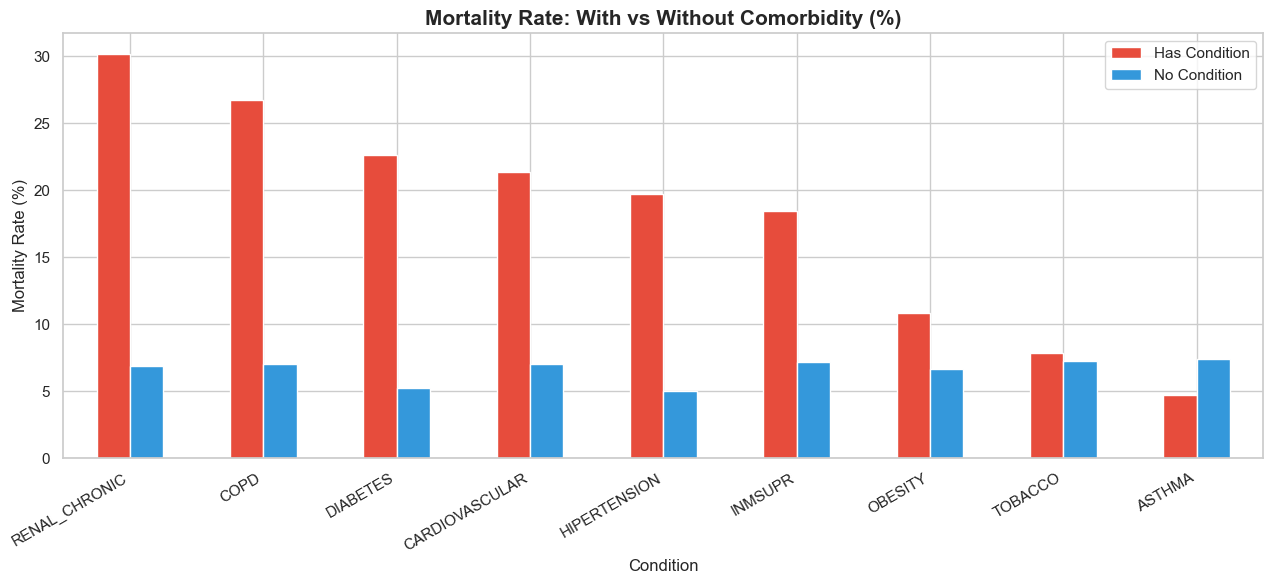

In [ ]:
# Mortality by Comorbidity
comorbidity_mortality = {}
for col in comorbidities:
    if col in df.columns:
        has_condition = df[df[col] == 1]['DIED'].mean() * 100
        no_condition = df[df[col] == 2]['DIED'].mean() * 100
        comorbidity_mortality[col] = {'Has Condition': has_condition, 'No Condition': no_condition}

comorbidity_mort_df = pd.DataFrame(comorbidity_mortality).T.sort_values('Has Condition', ascending=False)

comorbidity_mort_df.plot(kind='bar', figsize=(13, 6), color=['#e74c3c', '#3498db'], edgecolor='white')
plt.title('Mortality Rate: With vs Without Comorbidity (%)', fontsize=15, fontweight='bold')
plt.xlabel('Condition')
plt.ylabel('Mortality Rate (%)')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

---
## 🔥 Step 8: Correlation & Heatmap Analysis

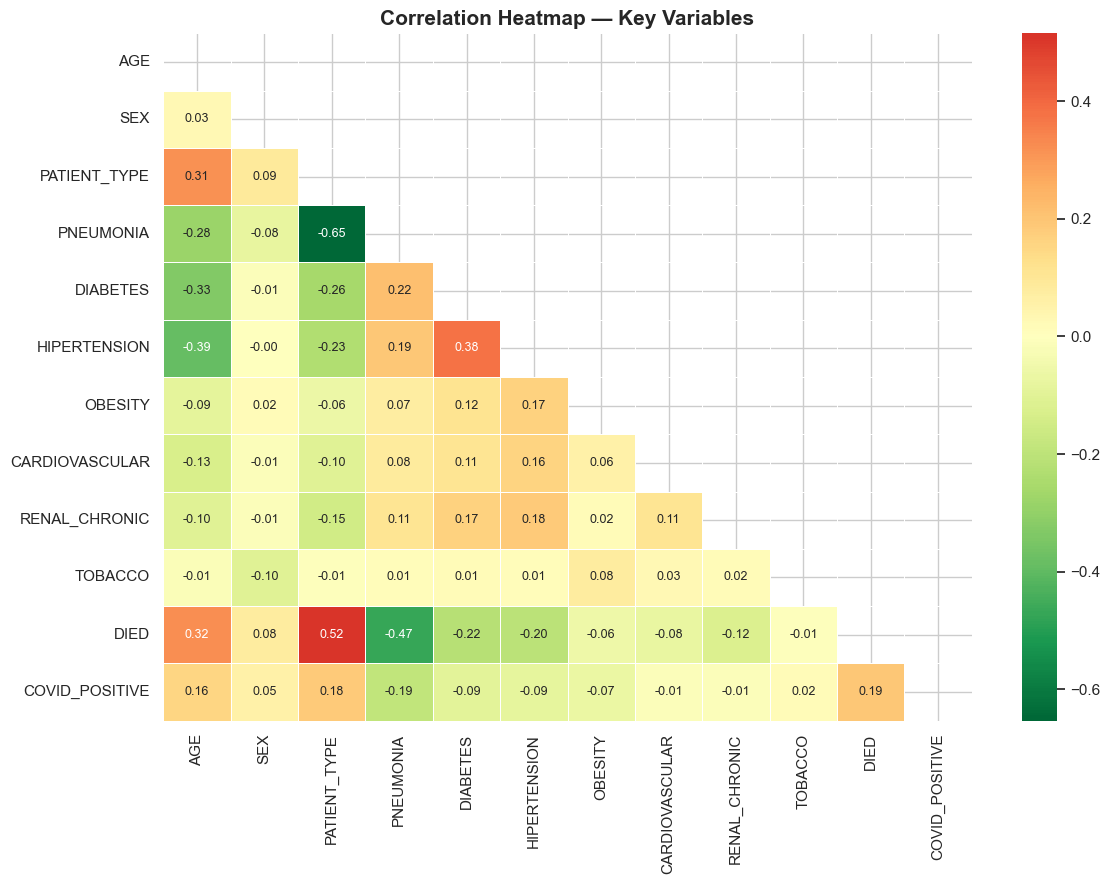

In [ ]:
# Correlation heatmap for key features
key_features = ['AGE', 'SEX', 'PATIENT_TYPE', 'PNEUMONIA', 'DIABETES',
                'HIPERTENSION', 'OBESITY', 'CARDIOVASCULAR', 'RENAL_CHRONIC',
                'TOBACCO', 'DIED', 'COVID_POSITIVE']

corr_df = df[key_features].copy()
# Replace 97/98/99 with NaN for correlation
corr_df = corr_df.replace([97, 98, 99], np.nan)

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn_r', center=0, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Correlation Heatmap — Key Variables', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📅 Step 9: Time Trend Analysis

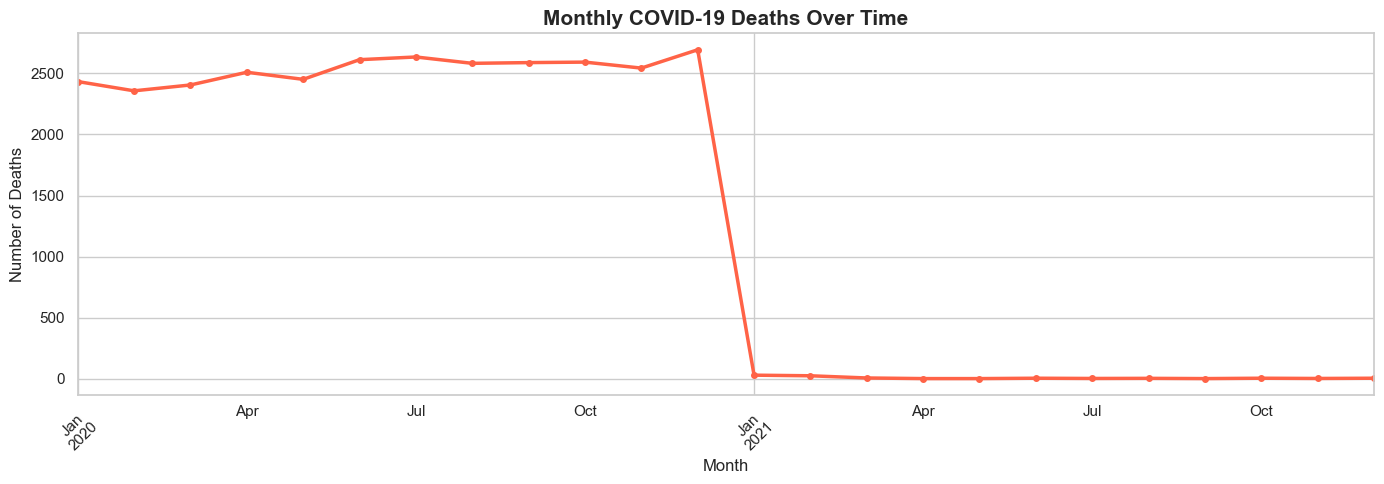

In [ ]:
# Deaths over time
deaths_over_time = df[df['DIED'] == 1]['DATE_DIED_PARSED'].dropna()
deaths_monthly = deaths_over_time.dt.to_period('M').value_counts().sort_index()

plt.figure(figsize=(14, 5))
deaths_monthly.plot(kind='line', color='tomato', linewidth=2.5, marker='o', markersize=4)
plt.title('Monthly COVID-19 Deaths Over Time', fontsize=15, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 🧪 Step 10: Hypothesis Testing

In [ ]:
from scipy import stats

# Hypothesis 1: Do patients who died have significantly higher age?
died_ages = df[df['DIED'] == 1]['AGE'].dropna()
survived_ages = df[df['DIED'] == 0]['AGE'].dropna()

t_stat, p_value = stats.ttest_ind(died_ages, survived_ages)
print('=== HYPOTHESIS TEST 1: Age vs Mortality ===')
print(f'Mean Age (Died):     {died_ages.mean():.1f}')
print(f'Mean Age (Survived): {survived_ages.mean():.1f}')
print(f'T-statistic: {t_stat:.3f} | P-value: {p_value:.5e}')
if p_value < 0.05:
    print('✅ RESULT: Statistically significant difference — older patients have higher mortality.')
else:
    print('❌ RESULT: No significant difference found.')

=== HYPOTHESIS TEST 1: Age vs Mortality ===
Mean Age (Died):     61.1
Mean Age (Survived): 40.3
T-statistic: 346.831 | P-value: 0.00000e+00
✅ RESULT: Statistically significant difference — older patients have higher mortality.


In [ ]:
# Hypothesis 2: Chi-Square test — Diabetes vs Mortality
from scipy.stats import chi2_contingency

# Filter for valid values only (1=Yes, 2=No)
valid = df[df['DIABETES'].isin([1, 2])]
contingency_table = pd.crosstab(valid['DIABETES'], valid['DIED'])
contingency_table.index = ['Has Diabetes', 'No Diabetes']
contingency_table.columns = ['Survived', 'Died']

chi2, p, dof, expected = chi2_contingency(contingency_table)

print('=== HYPOTHESIS TEST 2: Diabetes vs Mortality (Chi-Square) ===')
print(contingency_table)
print(f'\nChi2: {chi2:.2f} | P-value: {p:.5e} | DOF: {dof}')
if p < 0.05:
    print('✅ RESULT: Significant association between diabetes and mortality.')
else:
    print('❌ No significant association.')

=== HYPOTHESIS TEST 2: Diabetes vs Mortality (Chi-Square) ===
              Survived   Died
Has Diabetes     96724  28265
No Diabetes     872302  47946

Chi2: 49306.88 | P-value: 0.00000e+00 | DOF: 1
✅ RESULT: Significant association between diabetes and mortality.


In [ ]:
# Hypothesis 3: Is hospitalization rate different for COVID-positive vs negative?
pos = df[df['COVID_POSITIVE'] == 1]['PATIENT_TYPE']
neg = df[df['COVID_POSITIVE'] == 0]['PATIENT_TYPE']

hosp_pos = (pos == 2).mean() * 100
hosp_neg = (neg == 2).mean() * 100

print('=== HYPOTHESIS TEST 3: COVID+ vs Hospitalization ===')
print(f'Hospitalization Rate (COVID+): {hosp_pos:.1f}%')
print(f'Hospitalization Rate (COVID-): {hosp_neg:.1f}%')

cont = pd.crosstab(df['COVID_POSITIVE'], df['PATIENT_TYPE'])
chi2_h, p_h, _, _ = chi2_contingency(cont)
print(f'Chi2: {chi2_h:.2f} | P-value: {p_h:.5e}')
if p_h < 0.05:
    print('✅ RESULT: COVID+ patients have significantly different hospitalization rates.')

=== HYPOTHESIS TEST 3: COVID+ vs Hospitalization ===
Hospitalization Rate (COVID+): 28.4%
Hospitalization Rate (COVID-): 13.5%
Chi2: 35190.62 | P-value: 0.00000e+00
✅ RESULT: COVID+ patients have significantly different hospitalization rates.


---
## ⚠️ Step 11: Anomaly & Data Quality Detection

In [ ]:
print('=== DATA QUALITY REPORT ===')

# Age outliers
age_outliers = df[(df['AGE'] > 110) | (df['AGE'] < 0)]
print(f'\n1. Age Outliers (< 0 or > 110): {len(age_outliers)}')

# Age distribution check
print(f'   Min Age: {df["AGE"].min()} | Max Age: {df["AGE"].max()}')

# Check pregnant males
pregnant_males = df[(df['SEX'] == 2) & (df['PREGNANT'] == 1)]
print(f'\n2. Pregnant Males (anomaly): {len(pregnant_males)}')

# Duplicate rows
duplicates = df.duplicated().sum()
print(f'\n3. Duplicate Rows: {duplicates}')

# Invalid classification codes
valid_classification = df['CLASIFFICATION_FINAL'].isin(range(1, 8))
invalid_class = (~valid_classification).sum()
print(f'\n4. Invalid CLASIFFICATION_FINAL codes: {invalid_class}')

# Summary of special codes across binary features
binary_cols = ['PNEUMONIA', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR',
               'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR',
               'OBESITY', 'RENAL_CHRONIC', 'TOBACCO']
print('\n5. Special Code Presence (97/98/99) in Binary Columns:')
for col in binary_cols:
    if col in df.columns:
        special = df[col].isin([97, 98, 99]).sum()
        if special > 0:
            print(f'   {col}: {special:,} special codes ({special/len(df)*100:.2f}%)')

print('\n✅ Data Quality Check Complete!')

=== DATA QUALITY REPORT ===

1. Age Outliers (< 0 or > 110): 22
   Min Age: 0 | Max Age: 121

2. Pregnant Males (anomaly): 0

3. Duplicate Rows: 812049

4. Invalid CLASIFFICATION_FINAL codes: 0

5. Special Code Presence (97/98/99) in Binary Columns:
   PNEUMONIA: 16,003 special codes (1.53%)
   DIABETES: 3,338 special codes (0.32%)
   COPD: 3,003 special codes (0.29%)
   ASTHMA: 2,979 special codes (0.28%)
   INMSUPR: 3,404 special codes (0.32%)
   HIPERTENSION: 3,104 special codes (0.30%)
   OTHER_DISEASE: 5,045 special codes (0.48%)
   CARDIOVASCULAR: 3,076 special codes (0.29%)
   OBESITY: 3,032 special codes (0.29%)
   RENAL_CHRONIC: 3,006 special codes (0.29%)
   TOBACCO: 3,220 special codes (0.31%)

✅ Data Quality Check Complete!


---
## 🏥 Step 12: ICU & Intubation Analysis

=== ICU & INTUBATION (Hospitalized Patients Only) ===
Total Hospitalized: 200,031
ICU Admission Rate: 8.43%
Intubation Rate:    16.83%


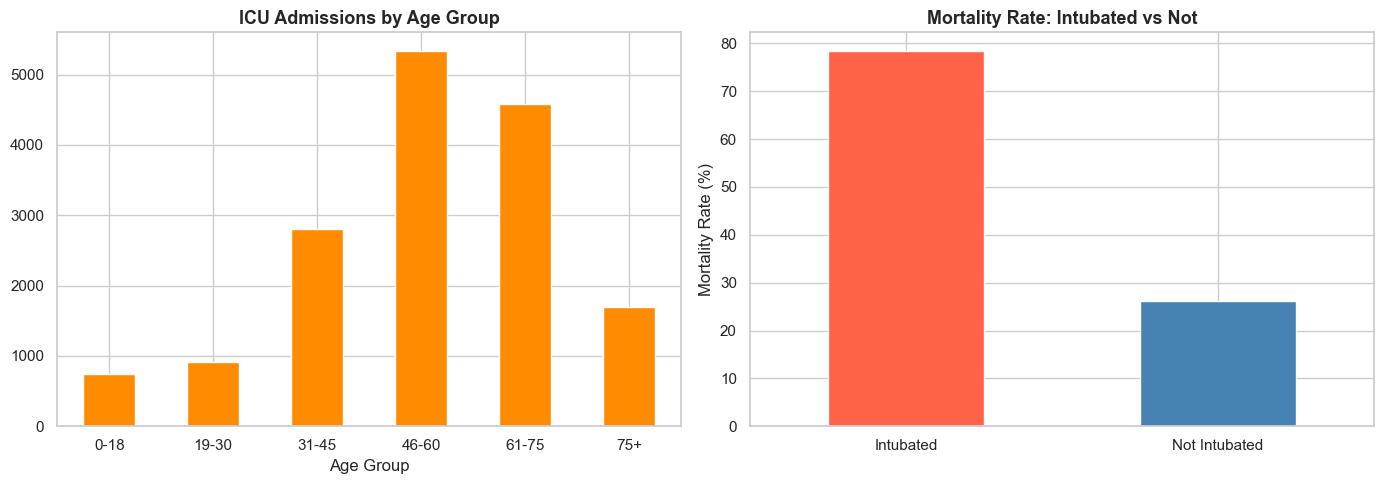

In [ ]:
# ICU & Intubation rates (among hospitalized patients only)
hospitalized = df[df['PATIENT_TYPE'] == 2]

icu_rate = (hospitalized['ICU'] == 1).sum() / len(hospitalized) * 100
intubated_rate = (hospitalized['INTUBED'] == 1).sum() / len(hospitalized) * 100

print(f'=== ICU & INTUBATION (Hospitalized Patients Only) ===')
print(f'Total Hospitalized: {len(hospitalized):,}')
print(f'ICU Admission Rate: {icu_rate:.2f}%')
print(f'Intubation Rate:    {intubated_rate:.2f}%')

# ICU by age group
icu_age = hospitalized[hospitalized['ICU'] == 1].groupby('AGE_GROUP').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
icu_age.plot(kind='bar', ax=axes[0], color='darkorange', edgecolor='white')
axes[0].set_title('ICU Admissions by Age Group', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].tick_params(axis='x', rotation=0)

# Intubation vs Outcome
intub_outcome = df[df['INTUBED'].isin([1, 2])].groupby('INTUBED')['DIED'].mean() * 100
intub_outcome.index = ['Intubated', 'Not Intubated']
intub_outcome.plot(kind='bar', ax=axes[1], color=['tomato', 'steelblue'], edgecolor='white')
axes[1].set_title('Mortality Rate: Intubated vs Not', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Mortality Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## 📝 Step 13: EDA Summary & Key Findings

In [ ]:
overall_mortality = df['DIED'].mean() * 100
hosp_rate = (df['PATIENT_TYPE'] == 2).mean() * 100
covid_pos_rate = df['COVID_POSITIVE'].mean() * 100

print('=' * 60)
print('         EDA SUMMARY — COVID-19 MEXICO DATASET')
print('=' * 60)
print(f'  Total Records:          {len(df):,}')
print(f'  Overall Mortality Rate: {overall_mortality:.2f}%')
print(f'  Hospitalization Rate:   {hosp_rate:.2f}%')
print(f'  COVID Positive Rate:    {covid_pos_rate:.2f}%')
print()
print('KEY FINDINGS:')
print('  1. Older patients (60+) have significantly higher mortality')
print('  2. Males have higher mortality than females')
print('  3. Pneumonia, Diabetes & Hypertension are most common comorbidities')
print('  4. Comorbidities (especially renal, cardiovascular) raise death risk')
print('  5. Intubated patients have much higher mortality (critical condition)')
print('  6. Some anomalies found: pregnant males, special codes (97/98/99)')
print('  7. COVID+ patients are significantly more likely to be hospitalized')
print()
print('RECOMMENDATIONS FOR FURTHER ANALYSIS:')
print('  - Build a mortality prediction model (Logistic Regression / Random Forest)')
print('  - Handle special codes (97/98/99) properly before modeling')
print('  - Investigate seasonal/wave patterns in the death trend')
print('  - Analyze interaction effects between multiple comorbidities')
print('=' * 60)

         EDA SUMMARY — COVID-19 MEXICO DATASET
  Total Records:          1,048,575
  Overall Mortality Rate: 7.34%
  Hospitalization Rate:   19.08%
  COVID Positive Rate:    37.38%

KEY FINDINGS:
  1. Older patients (60+) have significantly higher mortality
  2. Males have higher mortality than females
  3. Pneumonia, Diabetes & Hypertension are most common comorbidities
  4. Comorbidities (especially renal, cardiovascular) raise death risk
  5. Intubated patients have much higher mortality (critical condition)
  6. Some anomalies found: pregnant males, special codes (97/98/99)
  7. COVID+ patients are significantly more likely to be hospitalized

RECOMMENDATIONS FOR FURTHER ANALYSIS:
  - Build a mortality prediction model (Logistic Regression / Random Forest)
  - Handle special codes (97/98/99) properly before modeling
  - Investigate seasonal/wave patterns in the death trend
  - Analyze interaction effects between multiple comorbidities


---
*EDA Notebook — COVID-19 Mexico Dataset | Internship Task 2*